# Electron Diffusion Region Signatures

author: Louis Richard\
Computes and plots, for the four MMS spacecraft, quantities used to identify electron diffusion regions (EDRs), from the burst mode electric field (EDP) and electron and ion moments (FPI) and the survey magnetic field (FGM).

The quantities computed so far are:
- $\sqrt{Q}$ (Swisdak, 2016): values around 0.1 indicate electron agyrotropy. Computed from the off-diagonal terms of the pressure tensor for $P_{e\perp 1} = P_{e\perp 2}$.

- $D_{ng}$ (Aunai et al., 2013): computed from the off-diagonal terms of the pressure tensor for $P_{e\perp 1} = P_{e\perp 2}$. Similar to $\sqrt{Q}$ but with a different normalization. Computed but not plotted.

- $AG^{1/3}$ (Che et al., 2018): constructed from the determinant of the electron pressure tensor rotated into field-aligned coordinates ($P_{e\perp 1} = P_{e\perp 2}$).

- $A\Phi_e/2 = |P_{\perp 1} - P_{\perp 2}|/(P_{\perp 1} + P_{\perp 2})$: a measure of electron agyrotropy. Values of $O(1)$ are expected in EDRs. The pressure tensor is rotated into field-aligned coordinates such that the difference between $P_{e\perp 1}$ and $P_{e\perp 2}$ is maximal, which corresponds to $P_{23} = 0$. (This definition of agyrotropy neglects the off-diagonal pressure terms $P_{12}$ and $P_{13}$, so it does not capture all agyrotropies.)

- $A_{n_e} = T_\parallel/T_\perp$: values much larger than 1 are expected. Large $T_\parallel/T_\perp$ is a feature of the ion diffusion region (IDR). For magnetopause reconnection, MMS observations give $A_{n_e} \sim 3$ in ion diffusion regions. Scudder gives $A_{n_e} \sim 7$ at the IDR–EDR boundary, but this is extremely large for magnetopause reconnection.

- $M_{e\perp}$: electron Mach number, i.e., the bulk velocity divided by the electron thermal speed perpendicular to $\mathbf{B}$. Values of $O(1)$ are expected in EDRs (Scudder et al., 2012, 2015).

- $\mathbf{J}\cdot\mathbf{E}'$: $\mathbf{J}\cdot\mathbf{E}' > 0$ is expected in the EDR and corresponds to the dissipation of field energy. $\mathbf{J}$ is computed on each spacecraft from the particle moments (Zenitani et al., 2011).

- $\epsilon_e$: energy gain per cyclotron period. Values of $O(1)$ are expected in EDRs (Scudder et al., 2012, 2015).
- $\delta_e$: relative strength of the electric and magnetic forces in the electron bulk rest frame. N.B.: very sensitive to the electron moments and the electric field; check the version of these quantities (Scudder et al., 2012, 2015).

Notes:
$\kappa_e$ (not yet included) is taken to be the largest value of $\epsilon_e$ and $\delta_e$ at any given point. Requires electron distributions with version number v2.0.0 or higher. The agyrotropy measures (1)–(3) become unreliable at low densities, $n_e \lesssim 2~\mathrm{cm}^{-3}$, when the raw particle counts are low. Agyrotropies are removed for $n_e < 1~\mathrm{cm}^{-3}$.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from pyrfu import mms, pyrf
from pyrfu.plot import use_pyrfu_style, make_labels, pl_tx
from scipy import constants

use_pyrfu_style(usetex=False)

## Define time interval and data path

In [2]:
mms.db_init(default="local", local="/data/mms")
tint = ["2015-12-14T01:17:38.000", "2015-12-14T01:17:41.000"]

[05-Oct-26 17:39:47] INFO: Updating MMS data access configuration in /homelocal/louisr/.config/pyrfu/mms_config.json...
[05-Oct-26 17:39:47] WARNING: No system keyring available: MMS SDC credentials saved in plain text in /homelocal/louisr/.local/share/python_keyring/keyring_pass.cfg


## Load data

### Load fields

In [3]:
b_mms = [mms.get_data("b_dmpa_fgm_srvy_l2", tint, i) for i in range(1, 5)]
e_mms = [mms.get_data("e_dsl_edp_brst_l2", tint, i) for i in range(1, 5)]

[05-Oct-26 17:39:47] INFO: Loading mms1_fgm_b_dmpa_srvy_l2...
[05-Oct-26 17:39:48] INFO: Loading mms2_fgm_b_dmpa_srvy_l2...
[05-Oct-26 17:39:49] INFO: Loading mms3_fgm_b_dmpa_srvy_l2...
[05-Oct-26 17:39:50] INFO: Loading mms4_fgm_b_dmpa_srvy_l2...
[05-Oct-26 17:39:51] INFO: Loading mms1_edp_dce_dsl_brst_l2...
[05-Oct-26 17:39:51] INFO: Loading mms2_edp_dce_dsl_brst_l2...
[05-Oct-26 17:39:52] INFO: Loading mms3_edp_dce_dsl_brst_l2...
[05-Oct-26 17:39:52] INFO: Loading mms4_edp_dce_dsl_brst_l2...


### Load particle moments

In [4]:
n_mms_e = [mms.get_data("ne_fpi_brst_l2", tint, i) for i in range(1, 5)]
v_mms_e = [mms.get_data("ve_dbcs_fpi_brst_l2", tint, i) for i in range(1, 5)]
v_mms_i = [mms.get_data("vi_dbcs_fpi_brst_l2", tint, i) for i in range(1, 5)]
t_mms_e = [mms.get_data("te_dbcs_fpi_brst_l2", tint, i) for i in range(1, 5)]
p_mms_e = [mms.get_data("pe_dbcs_fpi_brst_l2", tint, i) for i in range(1, 5)]

[05-Oct-26 17:39:52] INFO: Loading mms1_des_numberdensity_brst...
[05-Oct-26 17:39:52] INFO: Loading mms2_des_numberdensity_brst...
[05-Oct-26 17:39:53] INFO: Loading mms3_des_numberdensity_brst...
[05-Oct-26 17:39:53] INFO: Loading mms4_des_numberdensity_brst...
[05-Oct-26 17:39:53] INFO: Loading mms1_des_bulkv_dbcs_brst...
[05-Oct-26 17:39:53] INFO: Loading mms2_des_bulkv_dbcs_brst...
[05-Oct-26 17:39:53] INFO: Loading mms3_des_bulkv_dbcs_brst...
[05-Oct-26 17:39:53] INFO: Loading mms4_des_bulkv_dbcs_brst...
[05-Oct-26 17:39:53] INFO: Loading mms1_dis_bulkv_dbcs_brst...
[05-Oct-26 17:39:53] INFO: Loading mms2_dis_bulkv_dbcs_brst...
[05-Oct-26 17:39:53] INFO: Loading mms3_dis_bulkv_dbcs_brst...
[05-Oct-26 17:39:53] INFO: Loading mms4_dis_bulkv_dbcs_brst...
[05-Oct-26 17:39:53] INFO: Loading mms1_des_temptensor_dbcs_brst...
[05-Oct-26 17:39:53] INFO: Loading mms2_des_temptensor_dbcs_brst...
[05-Oct-26 17:39:53] INFO: Loading mms3_des_temptensor_dbcs_brst...
[05-Oct-26 17:39:53] INFO: L

### Resample to DES sampling frequency

In [5]:
e_mms = [pyrf.resample(e_xyz, n_e) for e_xyz, n_e in zip(e_mms, n_mms_e)]
b_mms = [pyrf.resample(b_xyz, n_e) for b_xyz, n_e in zip(b_mms, n_mms_e)]
v_mms_i = [pyrf.resample(v_xyz_i, n_e) for v_xyz_i, n_e in zip(v_mms_i, n_mms_e)]

## Rotate pressure and temperature tensors

In [6]:
p_mms_e_pp = [
    mms.rotate_tensor(p_xyz, "fac", b_xyz, "pp") for p_xyz, b_xyz in zip(p_mms_e, b_mms)
]
p_mms_e_qq = [
    mms.rotate_tensor(p_xyz, "fac", b_xyz, "qq") for p_xyz, b_xyz in zip(p_mms_e, b_mms)
]
t_mms_e_fac = [
    mms.rotate_tensor(t_xyz, "fac", b_xyz) for t_xyz, b_xyz in zip(t_mms_e, b_mms)
]

## Compute EDR signatures

### Compute sqrt(Q) and Dng from Pe (pp)

In [7]:
sqrtq_mms = [pyrf.calc_sqrtq(p_pp) for p_pp in p_mms_e_pp]
dng_mms = [pyrf.calc_dng(p_pp) for p_pp in p_mms_e_pp]

### Compute agyrotropy measure AG^(1/3)

In [8]:
ag_mms = [pyrf.calc_ag(p_pp) for p_pp in p_mms_e_pp]
ag_cr_mms = [ag ** (1 / 3) for ag in ag_mms]

### Compute agyrotropy Aphi from Pe (qq)

In [9]:
agyro_mms = [pyrf.calc_agyro(p_qq) for p_qq in p_mms_e_qq]

### Remove spurious points

In [10]:
for sqrtq, dng, agyro, ag_cr in zip(sqrtq_mms, dng_mms, agyro_mms, ag_cr_mms):
    for coeff in [sqrtq, dng, agyro, ag_cr]:
        coeff_data = coeff.data.copy()
        for ii in range(len(coeff_data) - 1):
            if coeff[ii] > 2 * coeff[ii - 1] and coeff[ii] > 2 * coeff[ii + 1]:
                coeff_data[ii] = np.nan

        coeff.data = coeff_data

### Remove points with density below 1 cm^-3

In [11]:
for n_e, sqrtq, dng, agyro, ag_cr in zip(
    n_mms_e, sqrtq_mms, dng_mms, agyro_mms, ag_cr_mms
):
    sqrtq.data[n_e.data < 1] = np.nan
    dng.data[n_e.data < 1] = np.nan
    agyro.data[n_e.data < 1] = np.nan
    ag_cr.data[n_e.data < 1] = np.nan

### Compute temperature ratio An

In [12]:
t_rat_mms = [p_pp[:, 0, 0] / p_pp[:, 1, 1] for p_pp in p_mms_e_pp]

### Compute electron Mach number

In [13]:
qe, me = [constants.elementary_charge, constants.electron_mass]
v_mms_e_mag = [pyrf.norm(v_xyz_e) for v_xyz_e in v_mms_e]
v_mms_e_per = [
    np.sqrt((t_fac_e[:, 1, 1] + t_fac_e[:, 2, 2]) * qe / me) for t_fac_e in t_mms_e_fac
]
m_mms_e = [
    1e3 * v_e_mag / v_e_perp for v_e_mag, v_e_perp in zip(v_mms_e_mag, v_mms_e_per)
]

### Compute current density and J·E'

In [14]:
# Current density in nA m^-2
j_mms_moms = [
    1e18 * qe * n_e * (v_xyz_i - v_xyz_e)
    for n_e, v_xyz_i, v_xyz_e in zip(n_mms_e, v_mms_i, v_mms_e)
]
vexb_mms = [
    e_xyz.data + 1e-3 * pyrf.cross(v_xyz_e, b_xyz)
    for e_xyz, v_xyz_e, b_xyz in zip(e_mms, v_mms_e, b_mms)
]
# J (nA/m^2), E (mV/m), E.J (nW/m^3)
edotj_mms = [
    1e-3 * pyrf.dot(vexb_xyz, j_xyz) for vexb_xyz, j_xyz in zip(vexb_mms, j_mms_moms)
]

### Compute epsilon and delta parameters

In [15]:
w_mms_ce = [1e-9 * qe * pyrf.norm(b_xyz) / me for b_xyz in b_mms]
edotve_mms = [pyrf.dot(e_xyz, v_xyz_e) for e_xyz, v_xyz_e in zip(e_mms, v_mms_e)]
eps_mms_e = [
    np.abs(6 * np.pi * edotve_xyz / (w_ce * pyrf.trace(t_fac_e)))
    for edotve_xyz, w_ce, t_fac_e in zip(edotve_mms, w_mms_ce, t_mms_e_fac)
]
delta_mms_e = [
    1e-3 * pyrf.norm(vexb_xyz) / (v_xyz_e_per * pyrf.norm(b_xyz) * 1e-9)
    for vexb_xyz, v_xyz_e_per, b_xyz in zip(vexb_mms, v_mms_e_per, b_mms)
]

## Plot figure

In [16]:
legend_options = dict(ncol=4, frameon=True, loc="upper right")

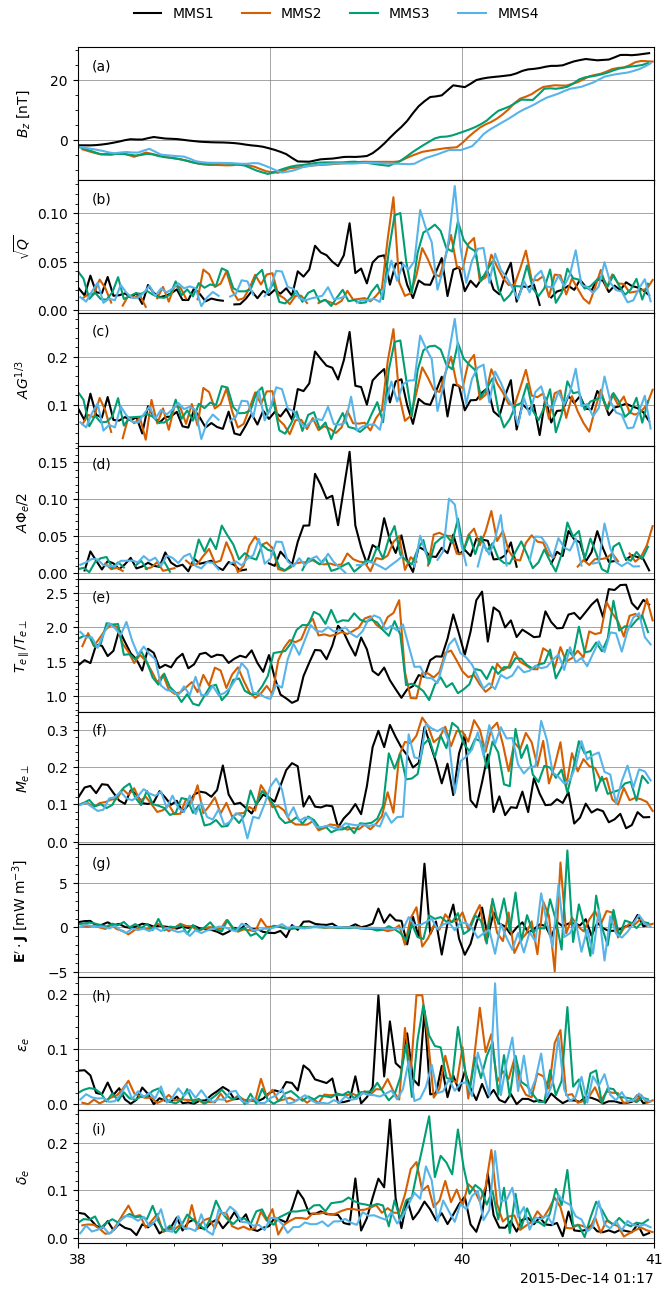

In [17]:
f, axs = plt.subplots(9, sharex="all", figsize=(9, 13))
f.subplots_adjust(hspace=0, left=0.18, right=0.82, bottom=0.05, top=0.97)

pl_tx(axs[0], b_mms, 2)
axs[0].set_ylabel(r"$B_{z}~[\mathrm{nT}]$")
labels = ["MMS{:d}".format(ic) for ic in range(1, 5)]
f.legend(
    labels=labels,
    loc="upper center",
    borderaxespad=0.1,
    ncol=4,
    frameon=False,
)

pl_tx(axs[1], sqrtq_mms, 0)
axs[1].set_ylabel(r"$\sqrt{Q}$")

pl_tx(axs[2], ag_cr_mms, 0)
axs[2].set_ylabel(r"$AG^{1/3}$")

pl_tx(axs[3], agyro_mms, 0)
axs[3].set_ylabel(r"$A\Phi_e / 2$")

pl_tx(axs[4], t_rat_mms, 0)
axs[4].set_ylabel(r"$T_{e\parallel}/T_{e \bot}$")

pl_tx(axs[5], m_mms_e, 0)
axs[5].set_ylabel(r"$M_{e \bot}$")

pl_tx(axs[6], edotj_mms, 0)
axs[6].set_ylabel(r"$\mathbf{E}'\cdot\mathbf{J}~[\mathrm{mW}~\mathrm{m}^{-3}]$")

pl_tx(axs[7], eps_mms_e, 0)
axs[7].set_ylabel(r"$\epsilon_{e}$")

pl_tx(axs[8], delta_mms_e, 0)
axs[8].set_ylabel(r"$\delta_{e}$")

make_labels(axs, [0.025, 0.83])

axs[-1].set_xlim(pyrf.iso86012datetime64(np.array(tint)))
f.align_ylabels(axs)